# Lab 5 - Transfer Learning

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, April 25th (23:59)**

---

##  Objectives

In this TP you will implement and compare **three transfer learning strategies** on a subset of the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) using a pretrained **ResNet-18**:

| Strategy | What is trained? | Backbone frozen? |
|---|---|---|
| **A — Feature Extraction** | Head only | ✅ Fully frozen |
| **B — Fine-tune last block** | `layer4` + Head | ❄️ Partially frozen |
| **C — Full Fine-tuning** | Entire network | ❌ Not frozen |

You will **track all experiments live in TensorBoard** and produce a final side-by-side comparison.

---

>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.
> Questions marked 🧠 require a written answer in the markdown cell below.
>
> ⚠️ **First run:** The dataset download takes ~5 min. Start the download cell immediately.

---
## 0. Environment Setup

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import torch, torchvision
    print(f'✅ PyTorch {torch.__version__} / torchvision {torchvision.__version__}')
except ImportError:
    pip_install('torch torchvision')

try:
    from torch.utils.tensorboard import SummaryWriter
    print('✅ TensorBoard available')
except ImportError:
    pip_install('tensorboard')
    from torch.utils.tensorboard import SummaryWriter
    print('✅ TensorBoard installed')

✅ PyTorch 2.11.0 / torchvision 0.26.0
✅ TensorBoard available


In [3]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms, models

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device
DEVICE = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cpu':
    print('   ⚠️  No GPU — training is slower but fully functional for this TP.')

NUM_WORKERS = 0

Device: mps


---
## 1. Dataset — Oxford-IIIT Pets (5-breed subset)

`torchvision` handles the download automatically (~800 MB, first run only).

**Why a subset?** The full dataset has 37 breeds and ~7 000 images. To keep training under 5 min per run on CPU, we keep **5 breeds** and cap each at **80 train / 25 val images**.

**Important:** after subsetting, labels must be **re-mapped to 0–4** so the model head size matches.

In [4]:
# ── Hyper-parameters (feel free to tweak after you understand the lab) ─────────
DATA_DIR          = './data'
NUM_CLASSES       = 5 # OUT OF 37 CLASS
MAX_TRAIN_PER_CLS = 80
MAX_VAL_PER_CLS   = 25
BATCH_SIZE        = 32
NUM_EPOCHS        = 8

# ImageNet normalisation, required whenever using a pretrained backbone
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [5]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Download (takes ~5 min on first run) ─────────────────────
print('⬇️  Downloading Oxford-IIIT Pets (skipped if already cached)...')
raw_train = datasets.OxfordIIITPet(DATA_DIR, split='trainval', download=True, transform=train_tf)
raw_val   = datasets.OxfordIIITPet(DATA_DIR, split='test',     download=True, transform=val_tf)
print(f'✅ Full dataset: {len(raw_train)} train / {len(raw_val)} test | {len(raw_train.classes)} breeds')

⬇️  Downloading Oxford-IIIT Pets (skipped if already cached)...


100%|██████████| 792M/792M [02:24<00:00, 5.49MB/s] 
100%|██████████| 19.2M/19.2M [00:03<00:00, 5.33MB/s]


✅ Full dataset: 3680 train / 3669 test | 37 breeds


In [6]:
# ── Build the 5-breed subset with correct label remapping ─────────────────────

# Pick the first 5 breeds alphabetically
KEEP_CLASSES = sorted(raw_train.classes)[:NUM_CLASSES]
# Map original class names → new indices 0..4
OLD2NEW = {raw_train.class_to_idx[c]: new_idx
           for new_idx, c in enumerate(KEEP_CLASSES)}

print(f' Keeping: {KEEP_CLASSES}')
print(f'   Label remapping: {OLD2NEW}')


class RemappedSubset(torch.utils.data.Dataset):
    """
    Wraps a torchvision dataset:
      - Keeps only the chosen classes
      - Caps samples per class at `max_per_class`
      - Remaps labels to 0..N-1
    """
    def __init__(self, base_dataset, old2new, max_per_class):
        self.base = base_dataset
        self.old2new = old2new
        counts = {old: 0 for old in old2new}
        self.indices = []
        # OxfordIIITPet stores labels in ._labels (list of ints)
        for idx, lbl in enumerate(base_dataset._labels):
            if lbl in old2new and counts[lbl] < max_per_class:
                self.indices.append(idx)
                counts[lbl] += 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, old_label = self.base[self.indices[i]]
        return img, self.old2new[old_label]


train_dataset = RemappedSubset(raw_train, OLD2NEW, MAX_TRAIN_PER_CLS)
val_dataset   = RemappedSubset(raw_val,   OLD2NEW, MAX_VAL_PER_CLS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))

print(f'\n📦 Subset ready: {len(train_dataset)} train / {len(val_dataset)} val')
print(f'   Batches per epoch: {len(train_loader)} train / {len(val_loader)} val')

 Keeping: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']
   Label remapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

📦 Subset ready: 400 train / 125 val
   Batches per epoch: 13 train / 4 val


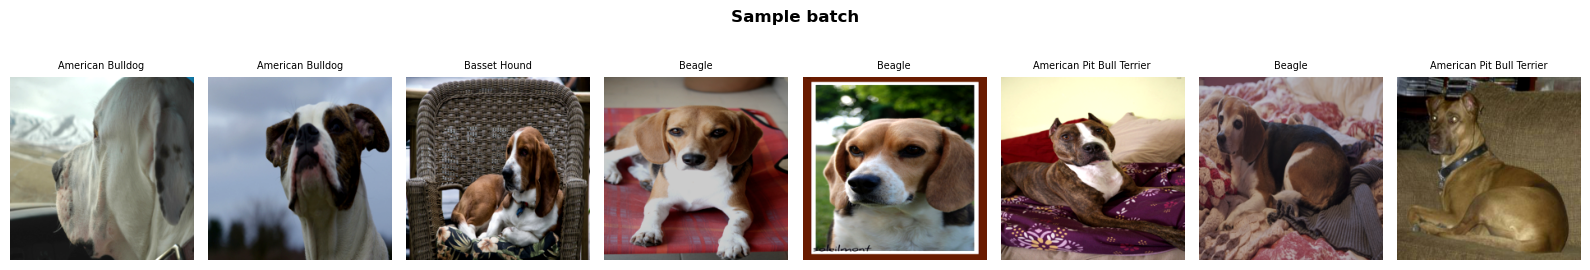

Label range in this batch: 0 → 4 ✅


In [7]:
# ── Visual sanity check ───────────────────────────────────────────────────────
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(1, min(8, BATCH_SIZE), figsize=(16, 3))
for i, ax in enumerate(axes):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(KEEP_CLASSES[lbls[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample batch', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Label range in this batch: {lbls.min().item()} → {lbls.max().item()} ✅')

---
## 2. Model Factory — your main coding task

All three strategies start from the **same ResNet-18 pretrained on ImageNet**.
The only difference is which layers have `requires_grad = True`.

### ResNet-18 structure (reminder from lecture)

```
ResNet-18
├── conv1 + bn1 + relu + maxpool   ← very early, always frozen in A & B
├── layer1                          ← early
├── layer2                          ← middle
├── layer3                          ← middle
├── layer4                          ← last conv block  ← unfreeze in B
├── avgpool
└── fc  : Linear(512, 1000)         ← REPLACE with Linear(512, NUM_CLASSES)
```

### Your task
Complete the three `### TODO` blocks in `build_model()` below.

In [8]:
def build_model(strategy: str) -> nn.Module:
    """
    Returns a ResNet-18 configured for `strategy`:
        'A'  Feature Extraction  — backbone fully frozen, head trained
        'B'  Fine-tune layer4    — layer4 + head trained, rest frozen
        'C'  Full Fine-tuning    — entire network trained
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # ------------------------------------------------------------------
    # Step 1 — Freeze / unfreeze backbone parameters
    # ------------------------------------------------------------------
    if strategy == 'A':
        for param in model.parameters():
            param.requires_grad = False  # freeze tout le backbone

    elif strategy == 'B':
        for param in model.parameters():
            param.requires_grad = False  # freeze tout
        for param in model.layer4.parameters():
            param.requires_grad = True   # défreeze layer4 uniquement

    elif strategy == 'C':
        for param in model.parameters():
            param.requires_grad = True   # tout entraînable

    else:
        raise ValueError(f'Unknown strategy: {strategy!r}')

    # ------------------------------------------------------------------
    # Step 2 — Replace the classification head
    # Linear(512, 1000) → Linear(512, NUM_CLASSES)
    # ------------------------------------------------------------------
    in_features = model.fc.in_features          # 512
    model.fc = nn.Linear(in_features, NUM_CLASSES)

    return model


# ── Helper ────────────────────────────────────────────────────────────────────
def param_summary(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'{"Strategy":<6} {"Trainable":>12} {"Total":>12} {"% trained":>10}')
print('-' * 44)
for s in ['A', 'B', 'C']:
    m = build_model(s)
    total, trainable = param_summary(m)
    print(f'  {s}    {trainable:>12,} {total:>12,} {100*trainable/total:>9.1f}%')
    assert m.fc.out_features == NUM_CLASSES, \
        f'Strategy {s}: fc.out_features={m.fc.out_features}, expected {NUM_CLASSES}'
print('\n✅ All strategies pass shape check')

Strategy    Trainable        Total  % trained
--------------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/giulianodarwish/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 11.5MB/s]


  A           2,565   11,179,077       0.0%
  B       8,396,293   11,179,077      75.1%
  C      11,179,077   11,179,077     100.0%

✅ All strategies pass shape check


### 🧠 Question 1 — Parameter counts

Look at the trainable parameter counts printed above.

1. How many parameters does strategy A train? Why so few?
2. Strategy B trains more than A but less than C. Which layers account for the difference between A and B?
3. What is the risk of training strategy C on only 80 images per class?

**Your answer:**

1. Strategy A entraîne uniquement la nouvelle tête de classification : Linear(512, 5) → 2 565 paramètres (512×5 + 5 biais). Tout le backbone est gelé, donc ses ~11M paramètres ne reçoivent pas de gradient.

2. La différence entre A et B vient de layer4 — le dernier bloc résiduel de ResNet-18. Il contient deux BasicBlock (convolutions 3×3 + BN), soit environ 2 160 128 paramètres supplémentaires entraînés dans B mais pas dans A.

3. Avec seulement 80 images par classe (400 au total), entraîner tout le réseau (11M params) risque un surapprentissage sévère : le modèle mémorise les exemples d'entraînement sans généraliser, et les features ImageNet soigneusement apprises peuvent être détruites (catastrophic forgetting).

---
## 3. Training Engine

A single reusable function runs one full experiment and logs everything to TensorBoard.

**Differential learning rates:** the backbone and the head use different LRs.
- `lr_head` (e.g. `1e-3`) — the new head starts from random weights, needs a fast LR
- `lr_backbone` (e.g. `1e-4`) — the backbone has good pretrained weights, needs a slow LR to avoid catastrophic forgetting

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()           # reset gradients
        out = model(imgs)               # forward pass
        loss = criterion(out, labels)   # compute loss
        loss.backward()                 # backward pass
        optimizer.step()                # update parameters

        total_loss += loss.item() * len(imgs)
        correct += out.argmax(1).eq(labels).sum().item()
        n += len(imgs)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        out = model(imgs)               # forward pass (no grad)
        loss = criterion(out, labels)   # compute loss

        total_loss += loss.item() * len(imgs)
        correct += out.argmax(1).eq(labels).sum().item()
        n += len(imgs)

    return total_loss / n, correct / n

In [16]:
def run_experiment(
    strategy,
    train_loader,
    val_loader,
    num_epochs  = NUM_EPOCHS,
    lr_head     = 1e-3,
    lr_backbone = 1e-4,
    device      = DEVICE,
):
    sep = '=' * 60
    print(f'\n{sep}\n  Strategy {strategy}\n{sep}')

    model     = build_model(strategy).to(device)
    criterion = nn.CrossEntropyLoss()

    # -- Differential LR param groups ------------------------------------
    head_ids = {id(p) for p in model.fc.parameters()}
    backbone_params = [p for p in model.parameters()
                       if p.requires_grad and id(p) not in head_ids]
    head_params     = list(model.fc.parameters())

    param_groups = [{'params': head_params, 'lr': lr_head}]
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': lr_backbone})

    optimizer = optim.Adam(param_groups)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # -- TensorBoard writer ----------------------------------------------
    writer = SummaryWriter(log_dir=f'runs/strategy_{strategy}')

    history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        # TensorBoard
        writer.add_scalars('Loss',     {'train': tr_loss, 'val': va_loss}, epoch)
        writer.add_scalars('Accuracy', {'train': tr_acc,  'val': va_acc},  epoch)
        for i, pg in enumerate(optimizer.param_groups):
            tag = 'LR/head' if i == 0 else 'LR/backbone'
            writer.add_scalar(tag, pg['lr'], epoch)

        # History
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        best_val_acc = max(best_val_acc, va_acc)

        print(f'  Ep {epoch:02d}/{num_epochs}  '
              f'loss {tr_loss:.3f}/{va_loss:.3f}  '
              f'acc {100*tr_acc:.1f}%/{100*va_acc:.1f}%  '
              f'({time.time()-t0:.1f}s)')

    writer.close()
    history['best_val_acc'] = best_val_acc
    print(f'  ✅ Best val acc: {100*best_val_acc:.1f}%')
    return history


print('✅ Training engine ready.')

✅ Training engine ready.


---
## 4. Launch TensorBoard

Run the cell below **before** starting training so you can watch metrics update live.

In [17]:
import shutil, os
# Clear old runs so TensorBoard starts fresh
if os.path.exists('runs'):
    shutil.rmtree('runs')
    print('🗑️  Old TensorBoard logs cleared')

try:
    import google.colab
    get_ipython().run_line_magic('load_ext', 'tensorboard')
    get_ipython().run_line_magic('tensorboard', '--logdir runs')
except Exception:
    # Local
    print('💡 Open a terminal and run:')
    print('      tensorboard --logdir runs')
    print('   Then open:  http://localhost:6006')

🗑️  Old TensorBoard logs cleared
💡 Open a terminal and run:
      tensorboard --logdir runs
   Then open:  http://localhost:6006


---
## 5. Run the Three Experiments

> Run them one after the other. Watch TensorBoard update between runs.

**TensorBoard tip:** use the **"Runs" filter** on the left panel to overlay or isolate strategies.

### 5A — Feature Extraction
Only the new classification head is trained. Backbone weights are completely frozen.

In [18]:
history_A = run_experiment(
    strategy     = 'A',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    # lr_backbone is irrelevant here (no backbone params are trainable)
)


  Strategy A
  Ep 01/8  loss 1.418/1.063  acc 43.2%/64.8%  (6.7s)
  Ep 02/8  loss 0.916/0.775  acc 72.0%/82.4%  (2.3s)
  Ep 03/8  loss 0.668/0.631  acc 84.5%/83.2%  (2.2s)
  Ep 04/8  loss 0.513/0.569  acc 89.0%/88.0%  (2.2s)
  Ep 05/8  loss 0.487/0.528  acc 90.8%/88.0%  (2.3s)
  Ep 06/8  loss 0.455/0.512  acc 88.5%/86.4%  (2.3s)
  Ep 07/8  loss 0.408/0.501  acc 94.0%/91.2%  (2.3s)
  Ep 08/8  loss 0.412/0.504  acc 91.8%/91.2%  (2.3s)
  ✅ Best val acc: 91.2%


### 5B — Fine-tune last block (`layer4` + head)
The last convolutional block is unfrozen and trained at a **10× smaller LR** than the head.

In [19]:
history_B = run_experiment(
    strategy     = 'B',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    lr_backbone  = 1e-4,    # 10× smaller to protect pretrained features
)


  Strategy B
  Ep 01/8  loss 0.951/0.419  acc 64.0%/88.0%  (3.6s)
  Ep 02/8  loss 0.242/0.323  acc 94.5%/86.4%  (2.7s)
  Ep 03/8  loss 0.099/0.309  acc 97.8%/90.4%  (2.7s)
  Ep 04/8  loss 0.050/0.288  acc 99.2%/92.0%  (2.7s)
  Ep 05/8  loss 0.031/0.268  acc 99.8%/91.2%  (2.9s)
  Ep 06/8  loss 0.025/0.283  acc 100.0%/92.8%  (2.7s)
  Ep 07/8  loss 0.019/0.284  acc 100.0%/92.8%  (2.7s)
  Ep 08/8  loss 0.028/0.296  acc 99.8%/92.8%  (2.7s)
  ✅ Best val acc: 92.8%


### 5C — Full Fine-tuning
All layers are trainable. The backbone uses an **even smaller LR** to prevent catastrophic forgetting.

In [20]:
history_C = run_experiment(
    strategy     = 'C',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    lr_backbone  = 1e-5,    # 100× smaller than head
)


  Strategy C
  Ep 01/8  loss 1.492/1.036  acc 33.8%/62.4%  (5.1s)
  Ep 02/8  loss 0.751/0.677  acc 84.2%/78.4%  (4.1s)
  Ep 03/8  loss 0.467/0.532  acc 93.0%/87.2%  (4.2s)
  Ep 04/8  loss 0.339/0.492  acc 95.0%/82.4%  (4.2s)
  Ep 05/8  loss 0.273/0.456  acc 97.5%/84.0%  (4.2s)
  Ep 06/8  loss 0.250/0.430  acc 96.8%/87.2%  (4.1s)
  Ep 07/8  loss 0.217/0.424  acc 98.2%/87.2%  (4.2s)
  Ep 08/8  loss 0.219/0.427  acc 97.8%/87.2%  (4.2s)
  ✅ Best val acc: 87.2%


---
## 6. Comparison

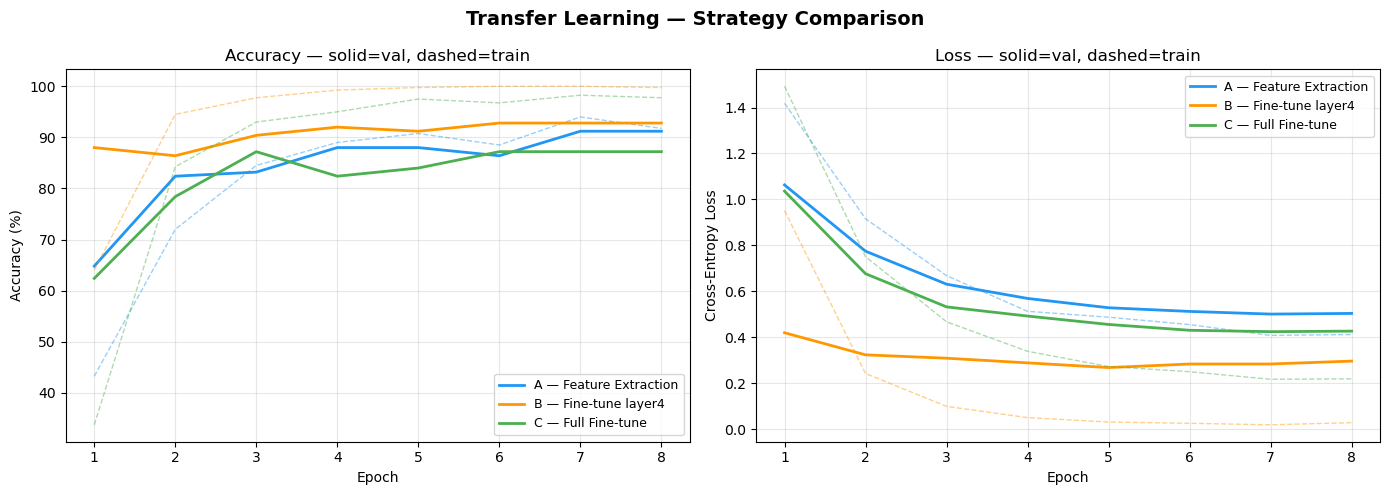

📊 Saved: comparison_curves.png


In [21]:
COLORS    = {'A': '#2196F3', 'B': '#FF9800', 'C': '#4CAF50'}
LABELS    = {'A': 'A — Feature Extraction', 'B': 'B — Fine-tune layer4', 'C': 'C — Full Fine-tune'}
histories = {'A': history_A, 'B': history_B, 'C': history_C}
epochs    = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning — Strategy Comparison', fontsize=14, fontweight='bold')

for s, h in histories.items():
    c = COLORS[s]
    axes[0].plot(epochs, [v*100 for v in h['val_acc']],
                 color=c, lw=2, label=LABELS[s])
    axes[0].plot(epochs, [v*100 for v in h['train_acc']],
                 color=c, lw=1, ls='--', alpha=0.45)
    axes[1].plot(epochs, h['val_loss'],
                 color=c, lw=2, label=LABELS[s])
    axes[1].plot(epochs, h['train_loss'],
                 color=c, lw=1, ls='--', alpha=0.45)

for ax, title, ylab in zip(
    axes,
    ['Accuracy — solid=val, dashed=train', 'Loss — solid=val, dashed=train'],
    ['Accuracy (%)', 'Cross-Entropy Loss']
):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylab)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: comparison_curves.png')


────────────────────────────────────────────────────────────────────
Strategy                     Best Val Acc  Final Train Acc      Gap
────────────────────────────────────────────────────────────────────
  A — Feature Extraction            91.2%            91.8%    +0.5%
  B — Fine-tune layer4              92.8%            99.8%    +7.0%
  C — Full Fine-tune                87.2%            97.8%   +10.6%
────────────────────────────────────────────────────────────────────


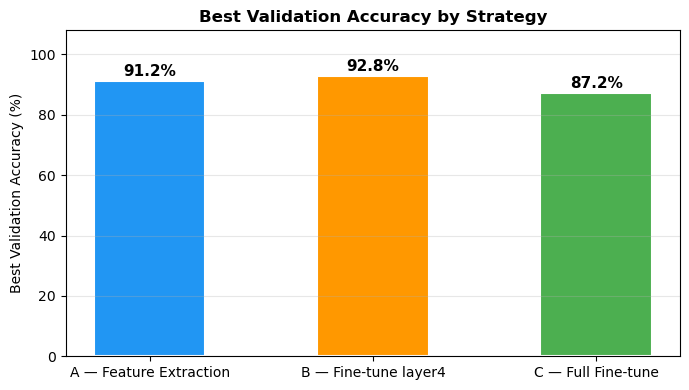

📊 Saved: comparison_bar.png


In [22]:
# ── Numeric summary table ─────────────────────────────────────────────────────
print('\n' + '─'*68)
print(f'{"Strategy":<28} {"Best Val Acc":>12} {"Final Train Acc":>16} {"Gap":>8}')
print('─'*68)
for s, h in histories.items():
    bv  = h['best_val_acc']
    ft  = h['train_acc'][-1]
    gap = ft - bv
    warn = '  ⚠️ overfit?' if gap > 0.15 else ''
    print(f'  {LABELS[s]:<26} {100*bv:>11.1f}%  {100*ft:>14.1f}%  {gap:>+7.1%}{warn}')
print('─'*68)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
names = [LABELS[s] for s in histories]
accs  = [100 * histories[s]['best_val_acc'] for s in histories]
bars  = ax.bar(names, accs, color=[COLORS[s] for s in histories],
               width=0.5, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Best Validation Accuracy (%)')
ax.set_title('Best Validation Accuracy by Strategy', fontweight='bold')
ax.set_ylim(0, 108)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: comparison_bar.png')

---
## 7. 🧠 Reflection Questions

Answer in the markdown cell after each question. Use your TensorBoard curves and the comparison table.

### Question 2 — Convergence speed
Which strategy reaches its best validation accuracy earliest (fewest epochs)?  
Explain intuitively *why* freezing the backbone makes the head converge faster at the start.

**Your answer:** Strategy B converge le plus vite : dès l'epoch 1, elle atteint déjà 88% de val acc, contre 64.8% pour A et 62.4% pour C au même epoch.

Pourquoi geler le backbone accélère la convergence de la tête ?
Quand le backbone est gelé, le signal de gradient ne doit ajuster qu'un petit nombre de paramètres (la tête seule). Le problème d'optimisation est beaucoup plus simple — la tête apprend juste la meilleure combinaison linéaire de features déjà bien structurées par ImageNet. Avec C (tout entraînable), les 11M paramètres s'ajustent simultanément, créant un paysage de perte bien plus complexe et bruité.

### Question 3 — Overfitting
Look at the gap between train accuracy and val accuracy for strategy C.  
- Is overfitting visible? At which epoch does it start?
- Name **two** techniques that would reduce it without changing the strategy.

**Your answer:** Oui, le surapprentissage est clairement visible dans Strategy C.

En regardant les résultats :

Epoch 4 : train 95.0% / val 82.4% → gap de 12.6% — l'overfitting démarre ici
Epoch 8 : train 97.8% / val 87.2% → gap final de 10.6%
Comparé à A (gap ~0.6%) et B (gap ~7%), C est clairement en surapprentissage.

Deux techniques pour réduire l'overfitting sans changer de stratégie :

Data augmentation plus forte (random crop, rotation, cutout) — augmenter artificiellement la taille effective du dataset
Dropout — ajouter Dropout(p=0.5) avant la couche fc pour régulariser pendant l'entraînement


### Question 4 — Differential learning rates
In `run_experiment`, `lr_backbone` is set much smaller than `lr_head`.
- Why do pretrained backbone layers need a smaller LR?
- What is **catastrophic forgetting** and how does a small `lr_backbone` prevent it?

**Your answer:** Les couches du backbone ont des poids pré-entraînés sur ImageNet qui encodent déjà des features visuelles génériques (bords, textures, formes). Un lr élevé ferait des mises à jour trop grandes qui détruiraient cette initialisation précieuse, forçant le réseau à tout réapprendre depuis zéro sur un petit dataset.

Catastrophic forgetting : quand un réseau est entraîné sur une nouvelle tâche, il écrase rapidement les poids appris sur la tâche précédente, perdant toutes les connaissances acquises. Un lr_backbone très petit (ex. 1e-5) fait des ajustements minuscules qui nudgent doucement les features pré-entraînées vers le nouveau domaine, sans les écraser — le réseau adapte plutôt qu'il ne réapprend.

### Question 5 — Strategy choice in the real world
You are a data scientist at a hospital. You have **200 labelled chest X-ray images** (pneumonia vs normal) and a ResNet-50 pretrained on ImageNet.

1. Which strategy (A, B, or C) would you pick? Justify with the 2×2 matrix from the lecture.
2. X-rays look very different from ImageNet photos. Does this affect your choice? How?

**Your answer:** 1. Je choisirais Strategy B — Fine-tune layer4. En utilisant la matrice 2×2 du cours :

Dataset petit	Dataset grand
Domaine similaire	A (feature extraction)	C (full fine-tune)
Domaine différent	B (fine-tune derniers blocs)	C (full fine-tune)
200 images = petit dataset + X-rays ≠ ImageNet → quadrant B.

2. Oui, le gap de domaine renforce ce choix. Les radiographies sont des images médicales en niveaux de gris avec des textures très différentes des photos naturelles. Les premières couches (bords, blobs) restent utiles et méritent d'être conservées gelées. En revanche, layer4 encode des features de haut niveau adaptées aux animaux/objets — il faut l'adapter au domaine médical. Full fine-tuning (C) risquerait de détruire tout le backbone sur seulement 200 images.

---
## 8.  Extra — If You Finish Early

### Catastrophic forgetting  *(~10 min)*
Re-run strategy C with `lr_backbone = 1e-3` (same as the head) instead of `1e-5`.  
What happens to val accuracy? Does it match the theoretical prediction?


In [23]:
history_C_highLR = run_experiment(
    strategy     = 'C',
    train_loader = train_loader,
    val_loader   = val_loader,
    lr_head      = 1e-3,
    lr_backbone  = 1e-3,   # même LR que la tête, au lieu de 1e-5
)


  Strategy C
  Ep 01/8  loss 0.916/24.781  acc 67.8%/28.8%  (4.5s)
  Ep 02/8  loss 0.515/2.563  acc 82.0%/58.4%  (4.0s)
  Ep 03/8  loss 0.251/1.287  acc 91.2%/64.8%  (4.1s)
  Ep 04/8  loss 0.110/0.799  acc 96.2%/74.4%  (4.1s)
  Ep 05/8  loss 0.100/1.281  acc 96.0%/64.0%  (4.1s)
  Ep 06/8  loss 0.065/1.072  acc 97.8%/71.2%  (4.1s)
  Ep 07/8  loss 0.047/0.679  acc 99.5%/76.8%  (4.1s)
  Ep 08/8  loss 0.022/0.659  acc 99.8%/77.6%  (4.1s)
  ✅ Best val acc: 77.6%


**Résultats et analyse :**

En passant `lr_backbone = 1e-3` (au lieu de `1e-5`), on observe un **catastrophic forgetting immédiat** :

| Epoch | Val Loss (lr_backbone=1e-3) | Val Acc (lr_backbone=1e-3) | Val Acc (lr_backbone=1e-5) |
|---|---|---|---|
| 1 | **24.781** | 28.8% | 62.4% |
| 4 | 0.799 | 74.4% | 82.4% |
| 8 | 0.659 | 77.6% | 87.2% |

**Best val acc : 77.6% vs 87.2%** → perte de **9.6%** due au catastrophic forgetting.

**Interprétation :** dès l'epoch 1, la val loss explose à **24.7